In [60]:
import os
import cv2
import cv2 as cv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [61]:
def generate_density_map(shape, points, sigma=4):
    H, W = shape
    density = np.zeros((H, W), dtype=np.float32)

    for x, y in points:
        x, y = int(x), int(y)
        if x >= W or y >= H:
            continue
        density[y, x] += 1

    # FIX 1: kernel size must be >= 6*sigma+1 to avoid clipping the Gaussian
    ksize = int(6 * sigma + 1) | 1  # ensure odd; = 25 for sigma=4
    density = cv2.GaussianBlur(density, (ksize, ksize), sigma)
    return density

In [62]:
class TrancosDataset(Dataset):
    def __init__(self, root, downsample_factor=1):
        self.downsample_factor = downsample_factor
        self.img_dir  = os.path.join(root, "images")
        self.dot_dir  = os.path.join(root, "dots")
        self.mask_dir = os.path.join(root, "ground-truth")

        self.images = sorted([f for f in os.listdir(self.img_dir) if f.endswith(".jpg")])

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path  = os.path.join(self.img_dir,  img_name)
        dot_path  = os.path.join(self.dot_dir,  img_name.replace(".jpg", ".txt"))
        # FIX 2: was missing underscore → produced e.g. "image001mask.mat"
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", "mask.mat"))

        # --- Image ---
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(
            img,
            (img.shape[1] // self.downsample_factor,
             img.shape[0] // self.downsample_factor)
        )

        # FIX 3: pad H and W to multiples of 8 so model output matches density size
        h, w, _ = img.shape
        h_pad = (8 - h % 8) % 8
        w_pad = (8 - w % 8) % 8
        if h_pad > 0 or w_pad > 0:
            img = cv2.copyMakeBorder(img, 0, h_pad, 0, w_pad, cv2.BORDER_REFLECT)
        h, w = img.shape[:2]

        # --- Points ---
        dot_path = os.path.join(self.dot_dir, img_name.replace(".jpg", "dots.png"))
        dot_img = cv2.imread(dot_path, cv2.IMREAD_COLOR)  # read as BGR
        if dot_img is not None:
            # red dots: high R, low G, low B (in BGR: high B index=2... no, BGR so R=channel 2)
            r = dot_img[:, :, 2]  # red channel in BGR
            g = dot_img[:, :, 1]
            b = dot_img[:, :, 0]
            red_mask = (r > 100) & (g < 50) & (b < 50)
            ys, xs = np.where(red_mask)
            xs = xs / self.downsample_factor
            ys = ys / self.downsample_factor
            points = np.stack([xs, ys], axis=1).astype(np.float32) if len(xs) > 0 else np.zeros((0, 2), dtype=np.float32)
        else:
            points = np.zeros((0, 2), dtype=np.float32)

        # --- Mask ---
        mat  = loadmat(mask_path)
        mask = mat["BW"]
        mask = cv2.resize(mask.astype(np.float32), (w, h))
        mask = (mask > 0).astype(np.float32)

        # FIX 4: cast back to uint8 BEFORE transform; float64 breaks ToTensor scaling
        img = (img * mask[:, :, None]).astype(np.uint8)

        # --- Density map ---
        density = generate_density_map((h, w), points)
        density = cv2.resize(density, (w // 8, h // 8))

        if density.sum() > 0:
            density *= (len(points) / density.sum())

        density *= 100.0

        img     = self.transform(img)
        density = torch.from_numpy(density).unsqueeze(0)

        return img, density

In [63]:
class CSRNet(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.frontend = nn.Sequential(*list(vgg.children())[:23])

        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2), nn.ReLU(),
            nn.Conv2d(128,  64, 3, padding=2, dilation=2), nn.ReLU()
        )

        self.output = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        return self.output(x)

In [64]:
DATA_ROOT = "TRANCOS - edited"

downsample_factor = 1  # adjust for memory constraints

train_ds = TrancosDataset(os.path.join(DATA_ROOT, "train_data"), downsample_factor=downsample_factor)
test_ds  = TrancosDataset(os.path.join(DATA_ROOT, "test_data"),  downsample_factor=downsample_factor)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

print("Train:", len(train_ds), "\nTest:", len(test_ds))

Train: 1031 
Test: 213


In [65]:
from torch.amp import autocast, GradScaler
scaler = GradScaler()

In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = CSRNet().to(device)

EPOCHS = 50
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# add a scheduler to reduce LR when loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

criterion = nn.MSELoss()
train_losses = []

for param in model.frontend.parameters():
    param.requires_grad = False
    
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    if epoch == 10:
        for param in model.frontend.parameters():
            param.requires_grad = True

    for i, (img, density) in enumerate(train_loader):
        img     = img.to(device)
        density = density.to(device)

        with autocast('cuda'):
            pred = model(img)
            loss = criterion(pred, density)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if i % 75 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Image {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} done | Avg Loss: {avg_loss:.4f}\n")

torch.save(model.state_dict(), "csrnet_trancos.pth")

Epoch 1/50 | Image 0/129 | Loss: 23.7908
Epoch 1/50 | Image 75/129 | Loss: 21.1077
Epoch 1 done | Avg Loss: 21.0319

Epoch 2/50 | Image 0/129 | Loss: 14.7788
Epoch 2/50 | Image 75/129 | Loss: 15.6618
Epoch 2 done | Avg Loss: 14.8144

Epoch 3/50 | Image 0/129 | Loss: 14.0291
Epoch 3/50 | Image 75/129 | Loss: 11.3498
Epoch 3 done | Avg Loss: 12.8103

Epoch 4/50 | Image 0/129 | Loss: 10.2421
Epoch 4/50 | Image 75/129 | Loss: 14.3413
Epoch 4 done | Avg Loss: 11.8617

Epoch 5/50 | Image 0/129 | Loss: 9.3106
Epoch 5/50 | Image 75/129 | Loss: 9.4823
Epoch 5 done | Avg Loss: 10.7301

Epoch 6/50 | Image 0/129 | Loss: 8.1430
Epoch 6/50 | Image 75/129 | Loss: 7.9812
Epoch 6 done | Avg Loss: 9.1867

Epoch 7/50 | Image 0/129 | Loss: 8.0568
Epoch 7/50 | Image 75/129 | Loss: 7.5201
Epoch 7 done | Avg Loss: 7.1236

Epoch 8/50 | Image 0/129 | Loss: 3.6751
Epoch 8/50 | Image 75/129 | Loss: 5.0141
Epoch 8 done | Avg Loss: 5.0492

Epoch 9/50 | Image 0/129 | Loss: 3.6170
Epoch 9/50 | Image 75/129 | Loss: 3

KeyboardInterrupt: 

In [69]:
model.load_state_dict(torch.load("csrnet_trancos.pth", weights_only=True))
model.eval()

CSRNet(
  (frontend): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

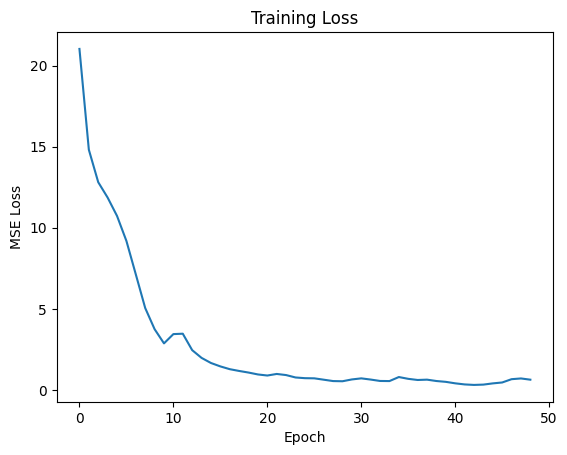

In [70]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

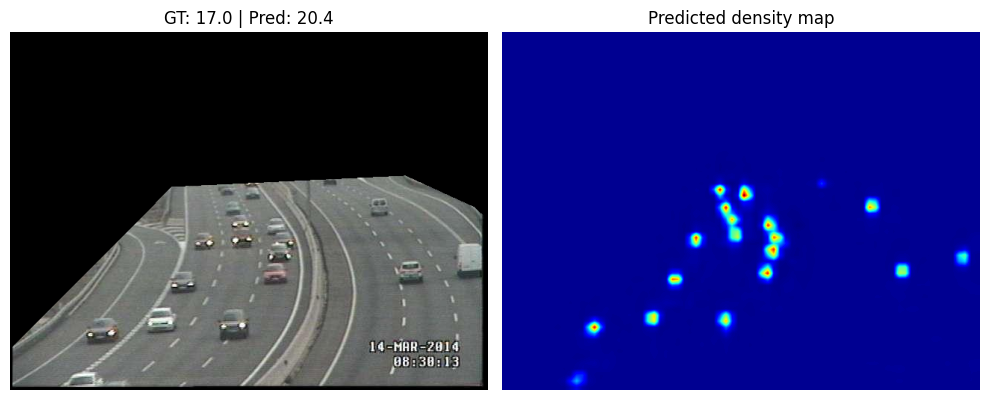

In [73]:
model.eval()

with torch.no_grad():
    for img, density in test_loader:

        img = img.to(device)
        pred = model(img)

        pred_count = pred.sum().item() / 100.0
        gt_count   = density.sum().item() / 100.0

        # Denormalise for display
        img_np = img[0].permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        density_map = pred[0, 0].cpu().numpy()
        density_map = cv2.resize(density_map, (img_np.shape[1], img_np.shape[0]))

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(img_np)
        plt.title(f"GT: {gt_count:.1f} | Pred: {pred_count:.1f}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(density_map, cmap="jet")
        plt.title("Predicted density map")
        plt.axis("off")

        plt.tight_layout()
        plt.show()
        break

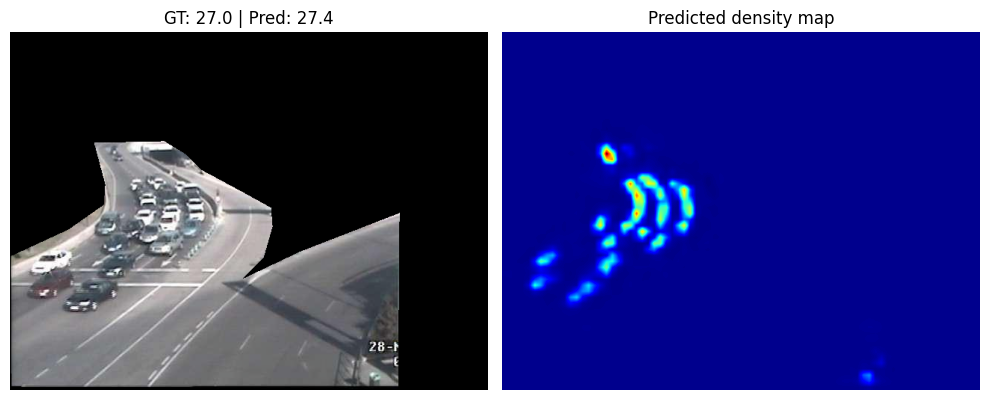

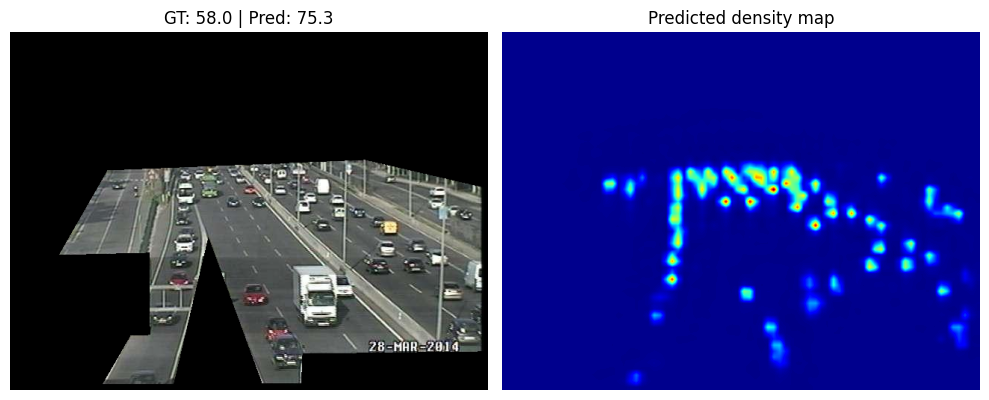

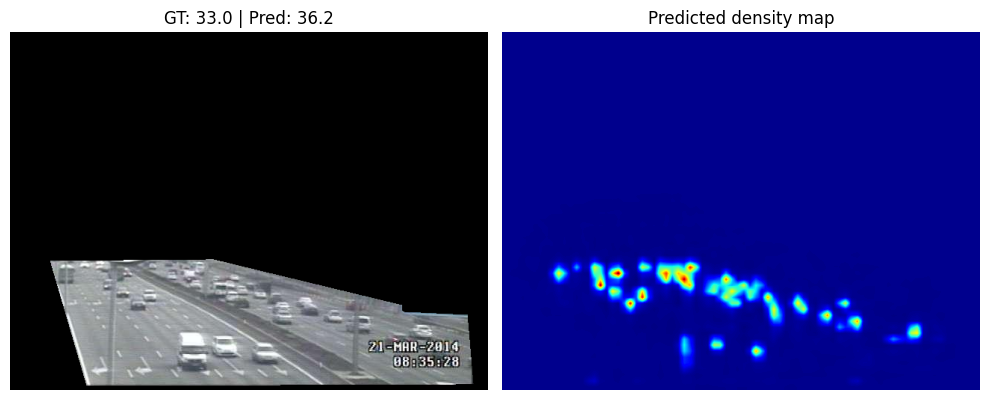

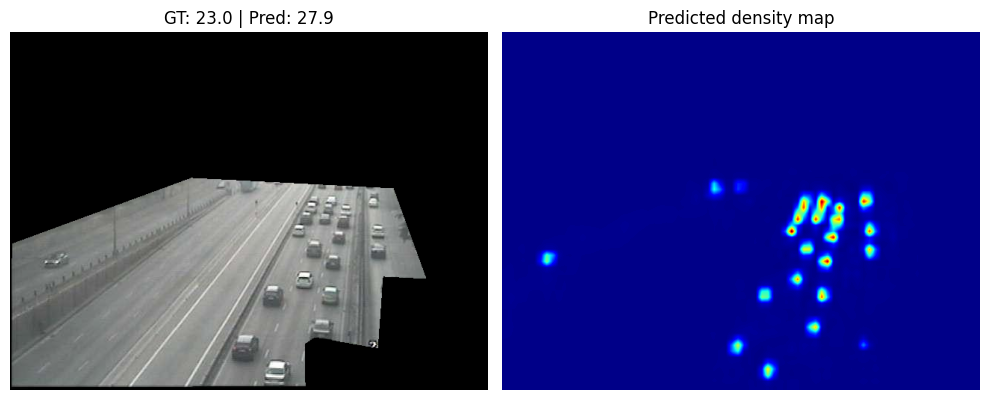

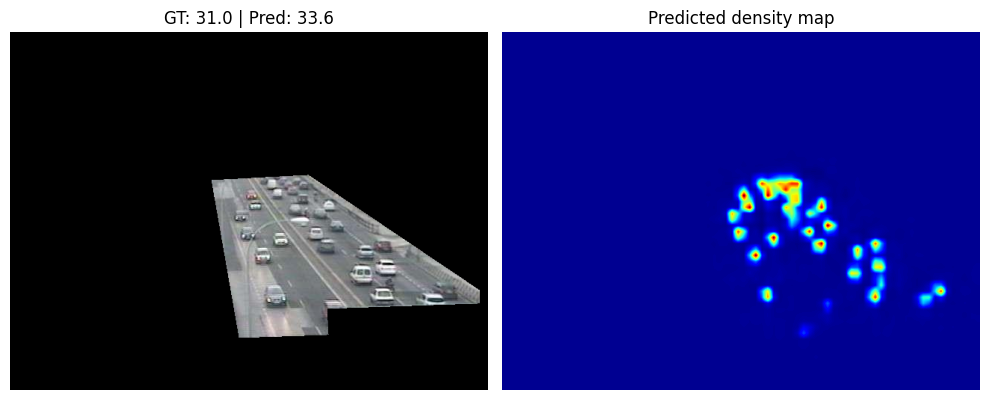

In [74]:
import random

model.eval()

indices = random.sample(range(len(test_ds)), 5)

with torch.no_grad():
    for idx in indices:
        img, density = test_ds[idx]
        img = img.unsqueeze(0).to(device)

        pred = model(img)

        pred_count = pred.sum().item() / 100.0
        gt_count   = density.sum().item() / 100.0

        img_np = img[0].permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        density_map = pred[0, 0].cpu().numpy()
        density_map = cv2.resize(density_map, (img_np.shape[1], img_np.shape[0]))

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(img_np)
        plt.title(f"GT: {gt_count:.1f} | Pred: {pred_count:.1f}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(density_map, cmap="jet")
        plt.title("Predicted density map")
        plt.axis("off")

        plt.tight_layout()
        plt.show()